## SCIP

**Concepts:** [Exact optimization](../routers.md#exact-optimization) **Reference:** [MILP Solvers](../reference/solvers.md) **Network/Router API:** [🎯 MILPRouter](hi23_milp.ipynb)

Solving the MILP model with SCIP (open source). The approach and the full solver roster are described in [Exact optimization](../routers.md#exact-optimization), the model options in [Model options](../routers.md#model-options), and the installation steps in [Install](../install.md).

In [1]:
from optiwindnet.heuristics import constructor
from optiwindnet.importer import load_repository
from optiwindnet.interarraylib import G_from_S
from optiwindnet.mesh import make_planar_embedding
from optiwindnet.MILP import ModelOptions, solver_factory
from optiwindnet.svg import svgplot

### Initialize Sheringham Shoal

In [2]:
locations = load_repository()

In [3]:
L = locations.sheringham
capacity = 6

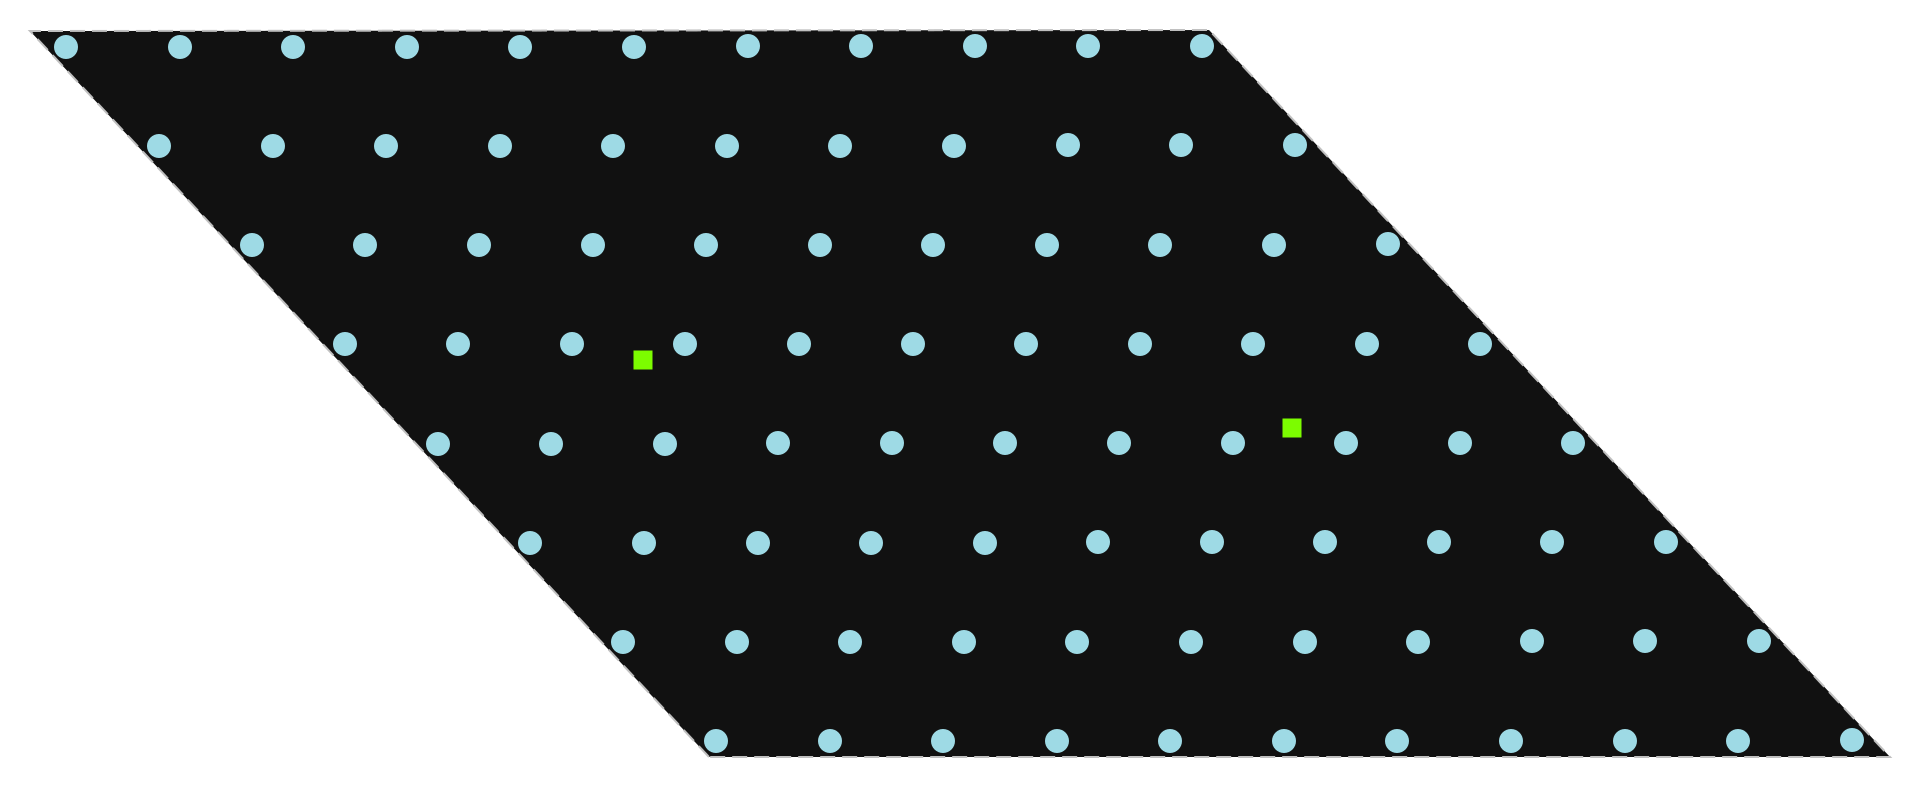

In [4]:
svgplot(L)

In [5]:
solver = solver_factory('scip')

### Optimize Sheringham Shoal

In [6]:
P, A = make_planar_embedding(L)

Initial heuristic solution to warm-start the solver:

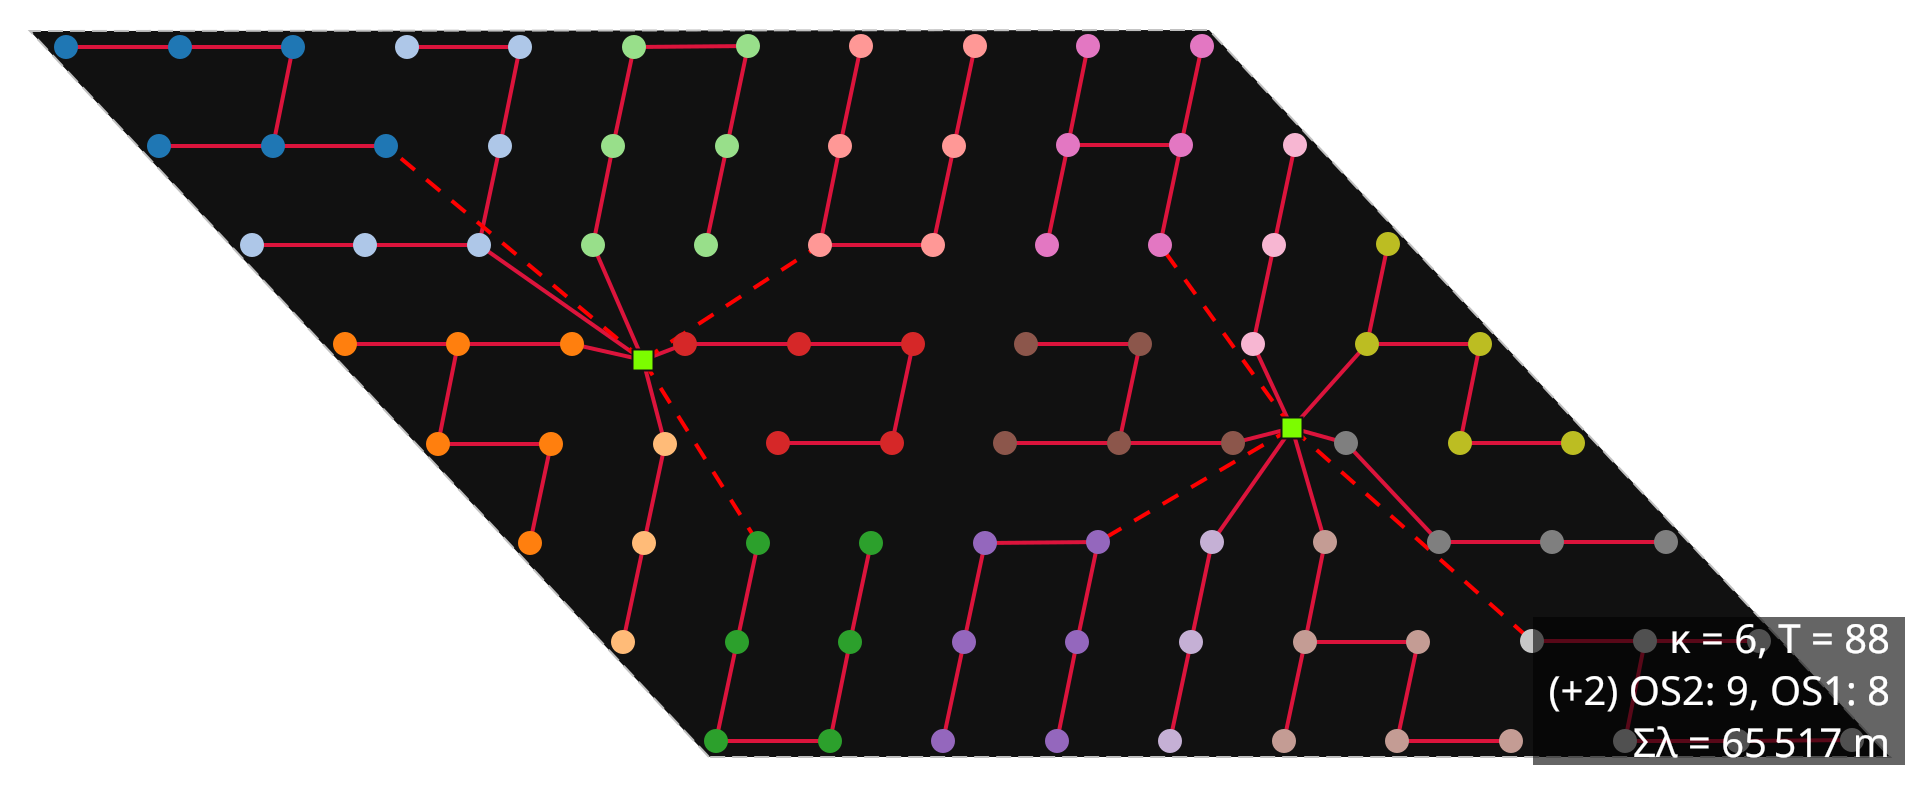

In [7]:
Sʹ = constructor(A, capacity=capacity)
Gʹ = G_from_S(Sʹ, A)
svgplot(Gʹ)

In [8]:
solver = solver_factory('scip')

If SCIP was compiled with multi-threading capability, multiple concurrent solver instances are started. OptiWindNet's default options prioritize launching feasibility-focused instances, but the choice of emphasis can be tuned by setting different weights.

OptiWindNet sets the maximum number of concurrent threads (`'parallel/maxnthreads'`) to the number of physical cores by default; assign a different value to `solver.options['parallel/maxnthreads']` before [set_problem()](../autoapi/optiwindnet/MILP/index.rst#optiwindnet.MILP.Solver.set_problem) to override. SCIP may still use a lower number than requested to limit RAM usage.

In [9]:
solver.options

{'parallel/maxnthreads': 8,
 'concurrent/scip-feas/prefprio': 0.6,
 'concurrent/scip/prefprio': 0.3,
 'concurrent/scip-cpsolver/prefprio': 0,
 'concurrent/scip-easycip/prefprio': 0,
 'concurrent/scip-opti/prefprio': 0}

The latest [SCIP Optimization Suite precompiled packages](https://www.scipopt.org/index.php#download) include multi-threading, but the PySCIPOpt wheel must be built on top of the library distributed in that package ([see instructions](https://pyscipopt.readthedocs.io/en/latest/build.html)). Latest versions at the time of writing: SCIP 10.0.0, PySCIPOpt 6.0. The conda-forge `pyscipopt` was at version 5.6.0 and was not concurrency-enabled for all platforms at the time ([check latest version](https://anaconda.org/channels/conda-forge/packages/pyscipopt/overview)).

In [10]:
solver.set_problem(
    P,
    A,
    capacity=Sʹ.graph['capacity'],
    model_options=ModelOptions(
        topology='branched',
        feeder_route='segmented',
        feeder_limit='unlimited',
    ),
    warmstart=Sʹ,
)

In [11]:
solver.solve(
    mip_gap=0.005,
    time_limit=60,
)

initializing seeds to 1963210296 in concurrent solver 'scip-2'
initializing seeds to 1332858414 in concurrent solver 'scip-feas-1'
initializing seeds to 1541326760 in concurrent solver 'scip-feas-2'
initializing seeds to 247360965 in concurrent solver 'scip-feas-3'
initializing seeds to 387742462 in concurrent solver 'scip-feas-4'
initializing seeds to 520723434 in concurrent solver 'scip-feas-5'
initializing seeds to 1176648445 in concurrent solver 'scip-3'
starting solve in concurrent solver 'scip-1'
starting solve in concurrent solver 'scip-2'
starting solve in concurrent solver 'scip-feas-4'
starting solve in concurrent solver 'scip-feas-5'
starting solve in concurrent solver 'scip-feas-2'
starting solve in concurrent solver 'scip-feas-1'
starting solve in concurrent solver 'scip-feas-3'
starting solve in concurrent solver 'scip-3'
 60.0s: concurrent solver 'scip-feas-4' stopped with status time limit reached
 60.0s: concurrent solver 'scip-feas-3' stopped with status time limit re

SolutionInfo(runtime=60.43258, bound=60731.2415979292, objective=62510.251645734315, relgap=0.028459492658697627, termination='timelimit')

> Note: If SCIP lacks multi-threading capability, a warning will be displayed and it will fall back to the single-threaded solver. The warning about the lack of concurrent capability looks like this:

```
.../optiwindnet/MILP/scip.py:96: UserWarning: SCIP was compiled without task processing interface. Parallel solve not possible - using optimize() instead of solveConcurrent()
 model.solveConcurrent()
```

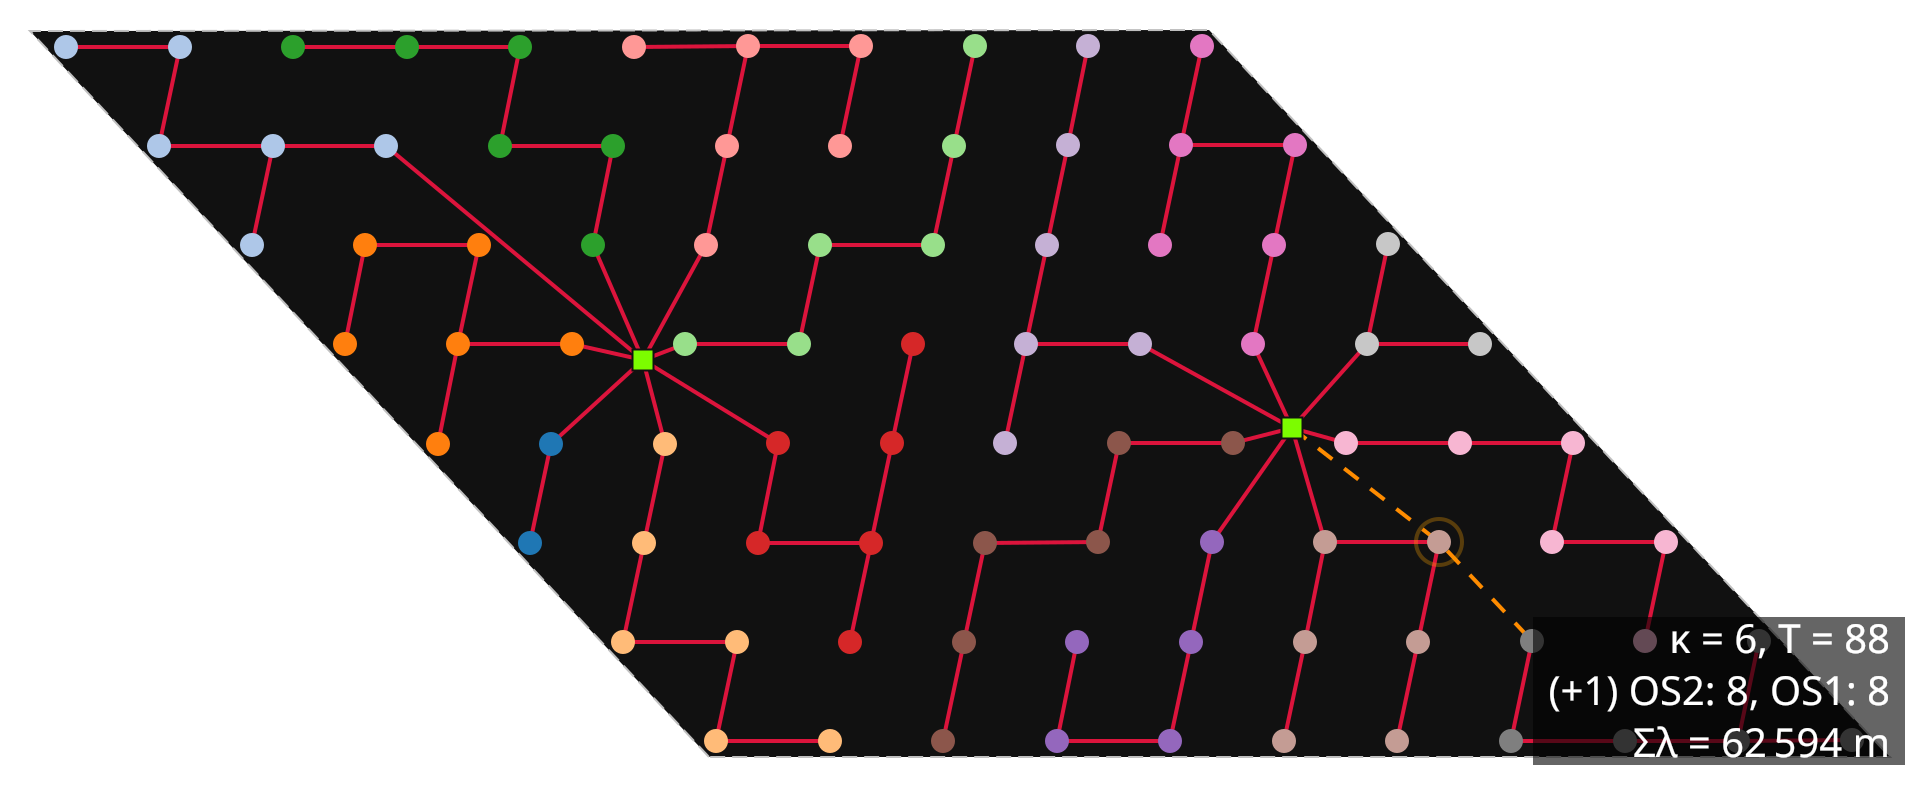

In [12]:
S, G = solver.get_solution()
svgplot(G)